    Income  Spending  Cluster
0       15        39       -1
1       16        81        0
2       17         6        1
3       18        77        0
4       30        40       -1
5       35        76        0
6       40         6        1
7       45        94        0
8       60         3        1
9       65        72       -1
10     150        10       -1


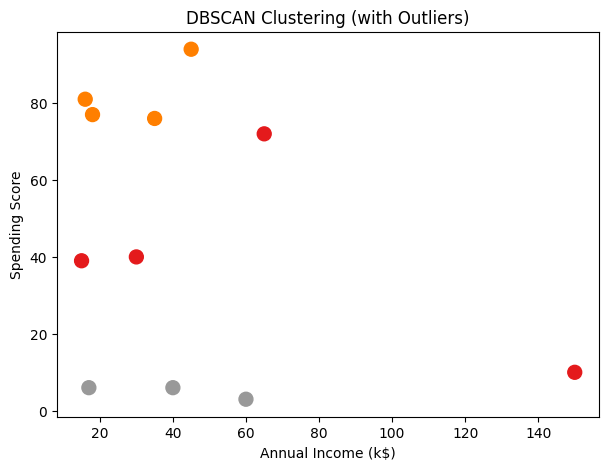

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


X=pd.DataFrame({
    'Income':[15,16,17,18,30,35,40,45,60,65,150],
    'Spending':[39,81,6,77,40,76,6,94,3,72,10]
})


scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)


dbscan=DBSCAN(eps=0.8,min_samples=3)
X['Cluster']=dbscan.fit_predict(x_scaled)
print(X)


plt.figure(figsize=(7,5))
plt.scatter(X['Income'], X['Spending'], c=X['Cluster'], cmap='Set1', s=100)
plt.title("DBSCAN Clustering (with Outliers)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()



eps=0.8,n_samples01

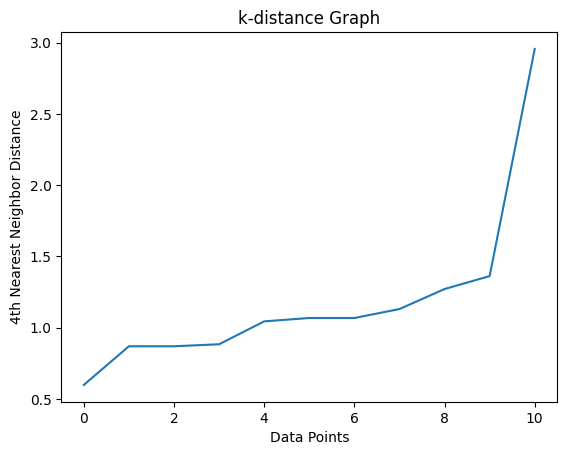

In [6]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Example data X_scaled from earlier
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(x_scaled)
distances, indices = neighbors_fit.kneighbors(x_scaled)


distances = np.sort(distances[:, 3])  # 3 = n_neighbors - 1
plt.plot(distances)
plt.title('k-distance Graph')
plt.xlabel('Data Points')
plt.ylabel('4th Nearest Neighbor Distance')
plt.show()



       id  age  gender  income  spending_score  membership_years  \
0       1   38  Female   99342              90                 3   
1       2   21  Female   78852              60                 2   
2       3   60  Female  126573              30                 2   
3       4   40   Other   47099              74                 9   
4       5   65  Female  140621              21                 3   
..    ...  ...     ...     ...             ...               ...   
995   996   57    Male  112170              57                 6   
996   997   23   Other   65337              76                10   
997   998   23    Male  113097              40                 5   
998   999   22  Female  113695              63                 7   
999  1000   36  Female   90420               7                 2   

     purchase_frequency preferred_category  last_purchase_amount  
0                    24          Groceries                113.53  
1                    42             Sports       

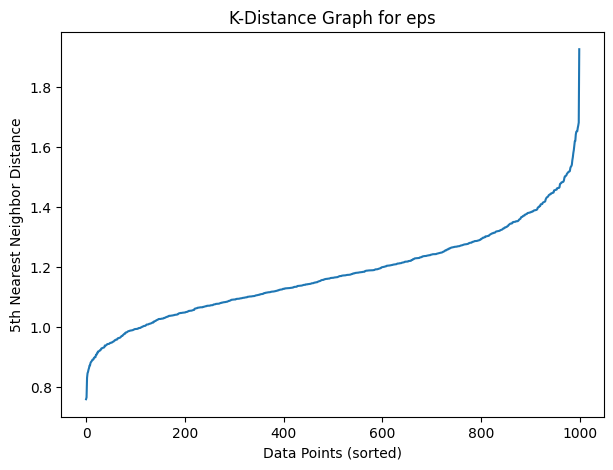

Cluster
-1    1000
Name: count, dtype: int64


ValueError: Could not interpret value `Annual Income (k$)` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors


df=pd.read_csv('customer_segmentation_data.csv')
print(df)


print(df.info())


df_num=df.select_dtypes(include=[np.number])
print(df_num.head())


df_num = df_num.drop(columns=['id'], errors='ignore')

df_num = df_num.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)


neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])
plt.figure(figsize=(7,5))
plt.plot(distances)
plt.title('K-Distance Graph for eps')
plt.xlabel('Data Points (sorted)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.show()


dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

df['Cluster'] = labels
print(df['Cluster'].value_counts())



plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

# Highlight Outliers
outliers = df[df['Cluster'] == -1]
plt.scatter(outliers['Annual Income (k$)'], outliers['Spending Score (1-100)'],
            c='black', s=150, marker='x', label='Outliers')

plt.title('DBSCAN Clustering on Customer Segmentation Data')
plt.legend()
plt.show()




1️⃣ DBSCAN ka basic idea (Simple words me)

DBSCAN ka full form: Density-Based Spatial Clustering of Applications with Noise

Matlab: Ye ek clustering algorithm hai jo data points ko densely populated areas me clusters me divide karta hai aur outliers/noise ko alag karta hai.

Do main cheezein define karte hain:

eps (epsilon) → Kitni doori ke andar points ko “same neighborhood” consider karenge

minPts (minimum points) → Ek cluster banne ke liye minimum points ka requirement



2️⃣ Points ke type (DBSCAN ke nazariye se)

Core Points

Ek point jiske neighborhood me minPts se zyada points hain.

Cluster ka center samjho.

Border Points

Jo core point ke neighborhood me hain lekin khud core point nahi hain.

Noise Points / Outliers

Jo kisi cluster ke neighborhood me nahi aate.


3️⃣ DBSCAN ka step by step process

Ek point choose karo jo visit nahi hua ho.

Uske eps radius ke andar points check karo.

Agar points ≥ minPts → Core point, cluster start karo

Us cluster ke saare points visit karo aur unke neighbors bhi add karo

Repeat karo jab tak cluster me aur points add na ho

Jo points kisi cluster me nahi aaye → Noise

In [1]:
from sklearn.cluster import DBSCAN
import numpy as np


x=np.array([
    [1,2],[2,2],[2,3],
    [8,7],[8,8],[25,80]
])

db=DBSCAN(eps=3,min_samples=2)
db.fit(x)

print("labels:",db.labels_)



labels: [ 0  0  0  1  1 -1]


Cluster 0:
  (1,2)  (2,2)  (2,3)

Cluster 1:
  (8,7)  (8,8)

Noise:
  (25,80)


In [2]:
from sklearn.cluster import DBSCAN
import numpy as np

x=np.array([
    [1,1],[1,2],[2,2],[2,3],[8,7],[8,8],[25,80],[9,7],[8,9]
])

db=DBSCAN(eps=2,min_samples=3)
labels=db.fit_predict(x)
print("labels:",labels)

labels: [ 0  0  0  0  1  1 -1  1  1]


   CustomerId  Annual_Income  Spending_score
0           1             15              39
1           2             16              81
2           3             17               6
3           4             20              77
4           5             90              40
5           6             88              38
6           7             86              50
7           8             87              60
8           9             25              15
9          10             23              82
   CustomerId  Annual_Income  Spending_score  Cluster
0           1             15              39       -1
1           2             16              81        0
2           3             17               6       -1
3           4             20              77        0
4           5             90              40        1
5           6             88              38        1
6           7             86              50       -1
7           8             87              60       -1
8           9      

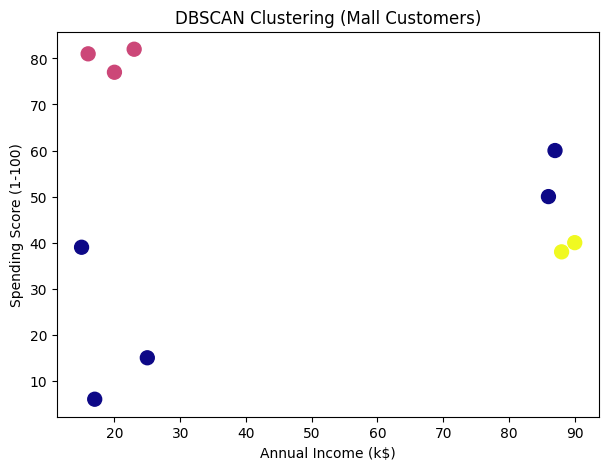

In [6]:
import pandas as pd

data=pd.DataFrame({
    'CustomerId':[1,2,3,4,5,6,7,8,9,10],
    'Annual_Income':[15, 16, 17, 20, 90, 88, 86, 87, 25, 23],
    'Spending_score':[39, 81, 6, 77, 40, 38, 50, 60, 15, 82]
})


print(data)


x=data[['Annual_Income','Spending_score']]


from sklearn.cluster import DBSCAN

dbscan=DBSCAN(eps=10,min_samples=2)
dbscan.fit(x)

data['Cluster']=dbscan.labels_
print(data)



import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(x['Annual_Income'],x['Spending_score'],c=dbscan.labels_,cmap='plasma',s=100)
plt.title('DBSCAN Clustering (Mall Customers)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

k means---k=4
dbscan----noise 

eps,min samp==2 3

    Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen  Cluster
0   12669   9656     7561     214              2674        1338        0
1    7057   9810     9568    1762              3293        1776        0
2    6353   8808     7684    2405              3516        7844       -1
3   13265   1196     4221    6404               507        1788       -1
4   22615   5410     7198    3915              5220        2013       -1
5    9413   8259     5126     666              1795        1451        0
6   12126   3199     6975     480              3140         545        0
7    7579   4956     9426     214              2993         256        0
8    5963   3648     6192    1336              2565        1321        0
9    6006  11093    18881    1159              7425        2098       -1
10   3366   5403     1295    3933               395         432       -1
11  13146   1124     1684    2192              1680         665       -1
12  31714  12319    14316     286              3181

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12532\1140004837.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


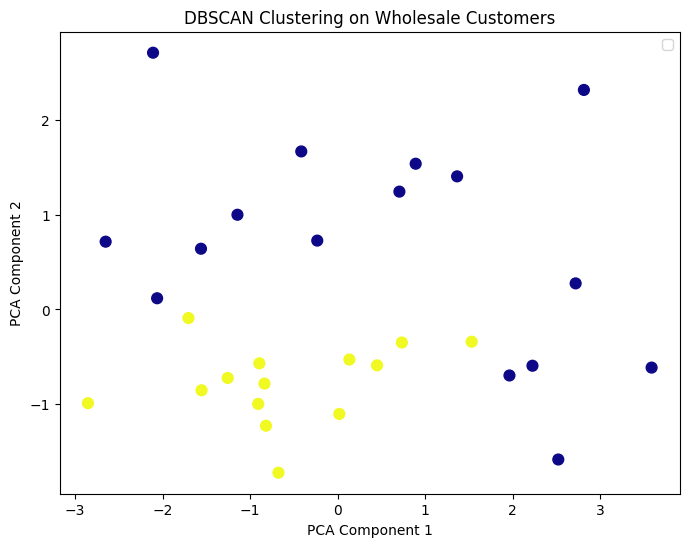

In [ ]:
import pandas as pd

data=pd.read_csv('wholesale_customers_large.csv')
# print(data)


# print(data.info())


X = data[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.5, min_samples=5)
db.fit(X_scaled)

data['Cluster'] = db.labels_
print(data)
print(data['Cluster'].value_counts())


from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=db.labels_, cmap='plasma', s=60)
plt.title("DBSCAN Clustering on Wholesale Customers")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11812\4141360932.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(xpoint,ypoint,alpha=0.5,s=sizes,cmap="prism")


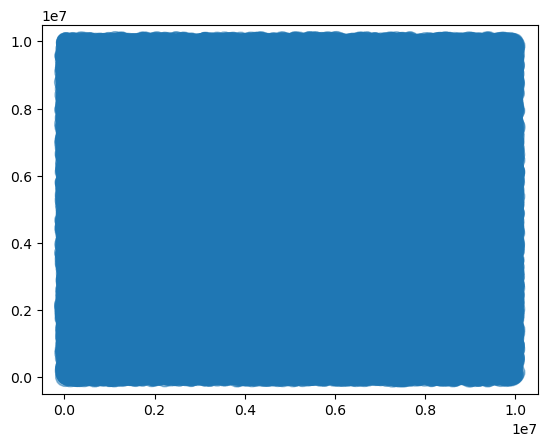

In [32]:
import matplotlib.pyplot as plt

import numpy as np

xpoint=np.random.randint(1,10000000,size=200000)
ypoint=np.random.randint(1,10000000,size=200000)

sizes=np.random.randint(1,200,size=200000)

plt.scatter(xpoint,ypoint,alpha=0.5,s=sizes,cmap="prism")
plt.show()

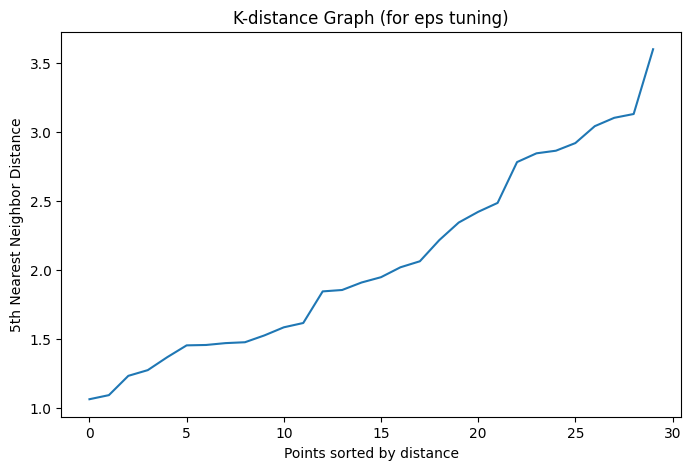

In [16]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors=NearestNeighbors(n_neighbors=5)
neighbors_fit=neighbors.fit(X_scaled)

distances,indices=neighbors.kneighbors(X_scaled)


distances = np.sort(distances[:,4])
plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-distance Graph (for eps tuning)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.show()